[2026-08-02 06:23:22] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-02 06:23:26] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-02 06:23:26] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-02 06:23:27] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-02 06:23:27] [info     ] ========== 数据检查 ==========
[2026-08-02 06:23:27] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_act

时段,IC
2024-01-15~2024-02-08,-0.0072
2024-09-24~2024-10-08,0.0174

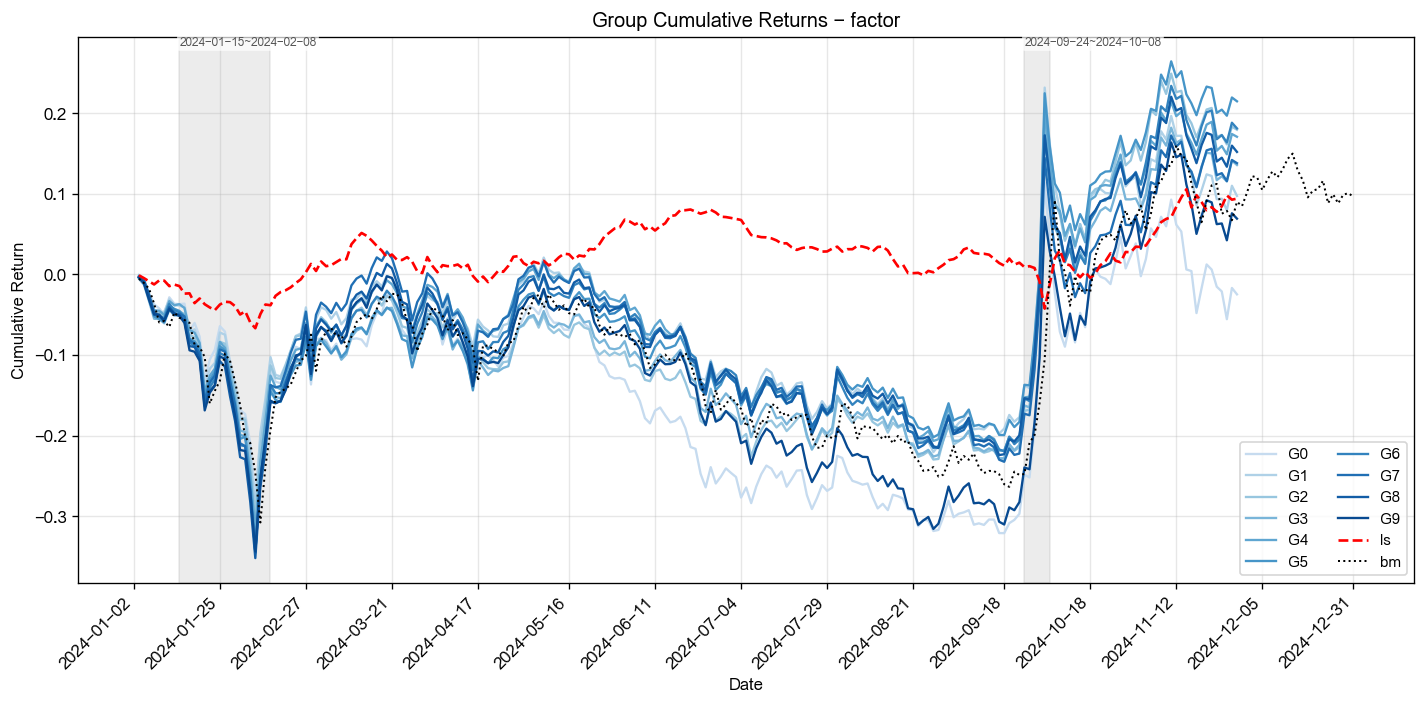
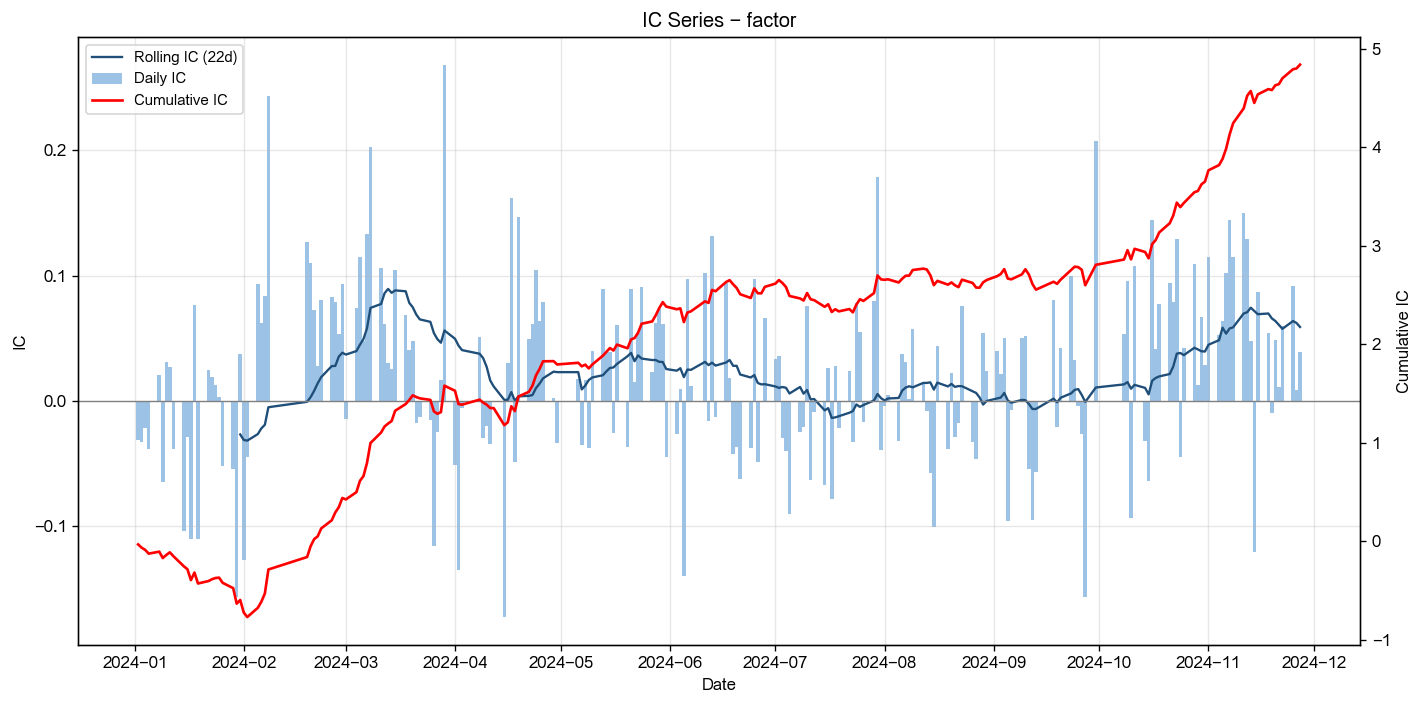
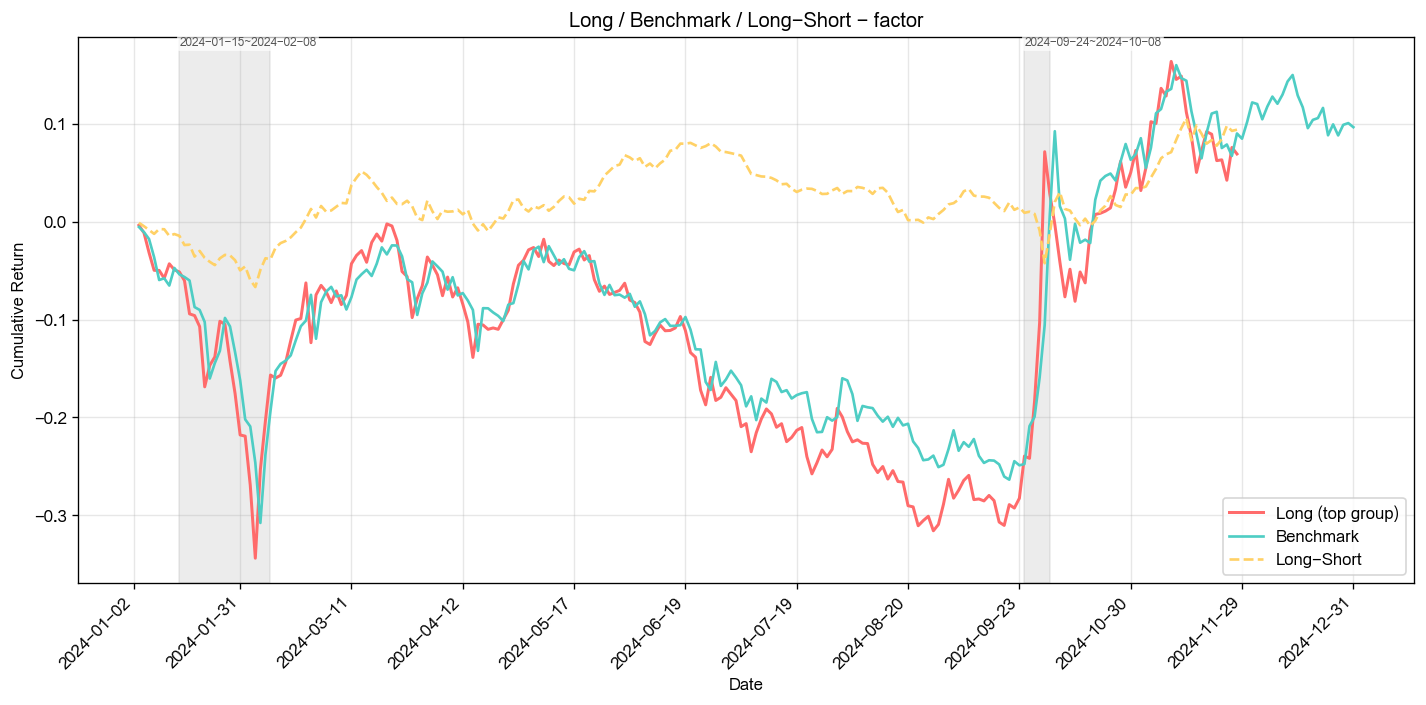
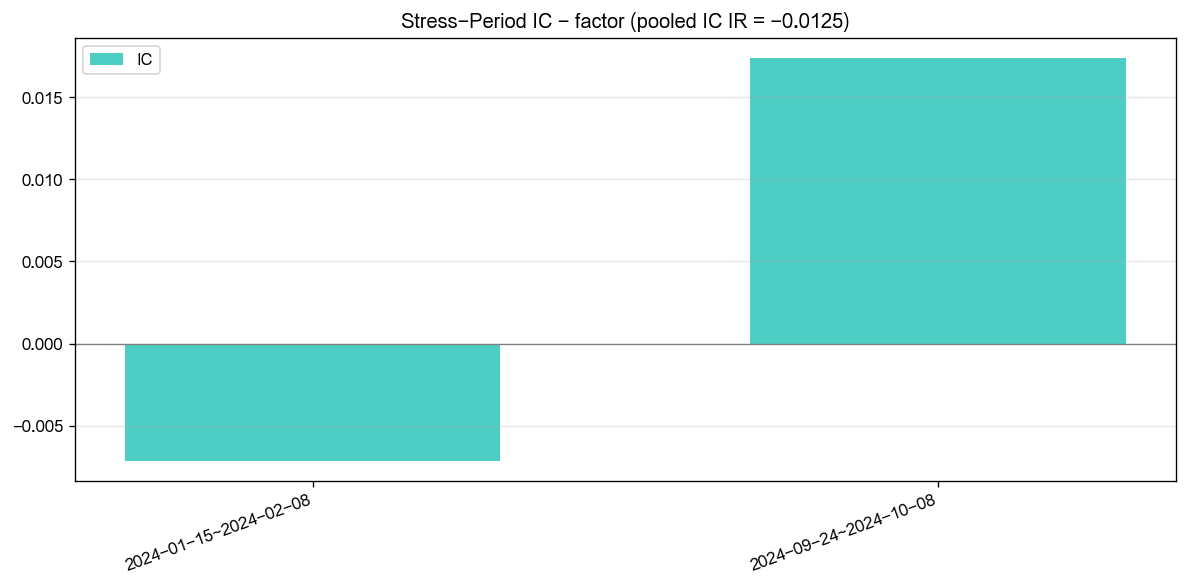
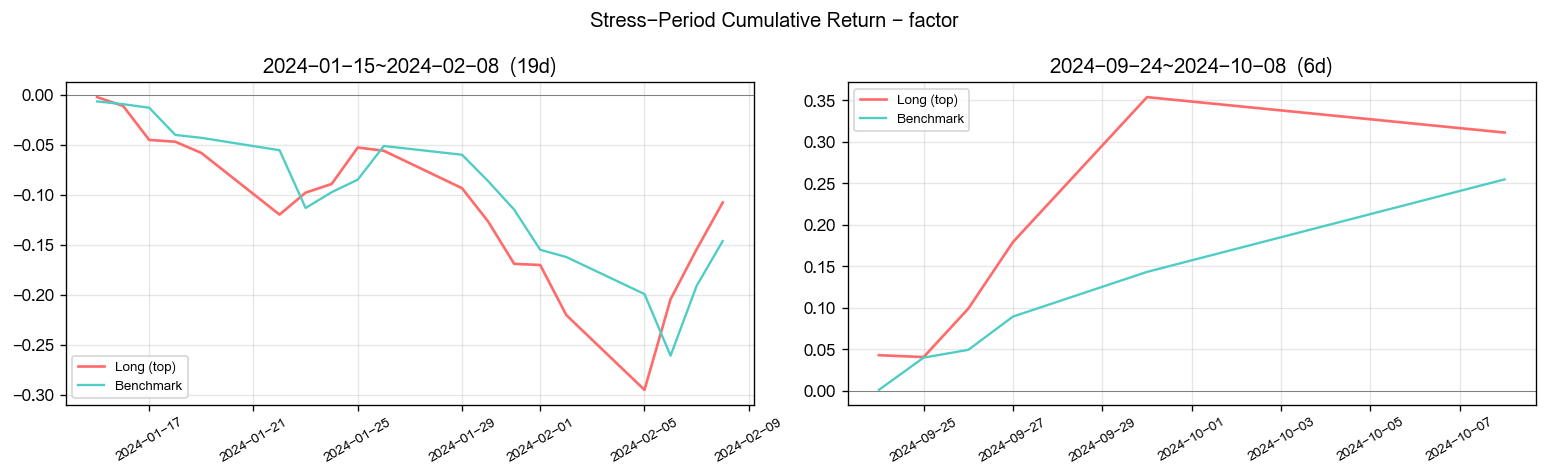

[2026-08-02 06:23:52] [info     ] ========== 因子池回归 ==========
[2026-08-02 06:23:52] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-02 06:23:52] [info     ] 获取收益率数据, 耗时: 0.9511 秒
[2026-08-02 06:23:53] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.4957 秒
[2026-08-02 06:23:53] [info     ] 统计 回归结果, 耗时: 0.093 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9973,0.0441,0.0221,1.0000
2,amount,1.7686,0.0186,0.0105,1.0000
3,netflow_amount_main,1.5061,0.0254,0.0169,1.0000
4,gross_profit_rate_ttm,1.4915,0.0068,0.0046,1.0000
5,net_profit_rate_ttm,1.4636,0.0041,0.0028,0.8000
6,factor,1.4341,0.0145,0.0101,0.9000
7,pb,1.4211,0.0099,0.0070,0.9000
8,bias_20,1.4099,0.0289,0.0205,0.9000
9,ps_ttm,1.3731,0.0037,0.0027,0.9000
10,netflow_amount_rate_main,1.3665,0.0088,0.0065,1.0000

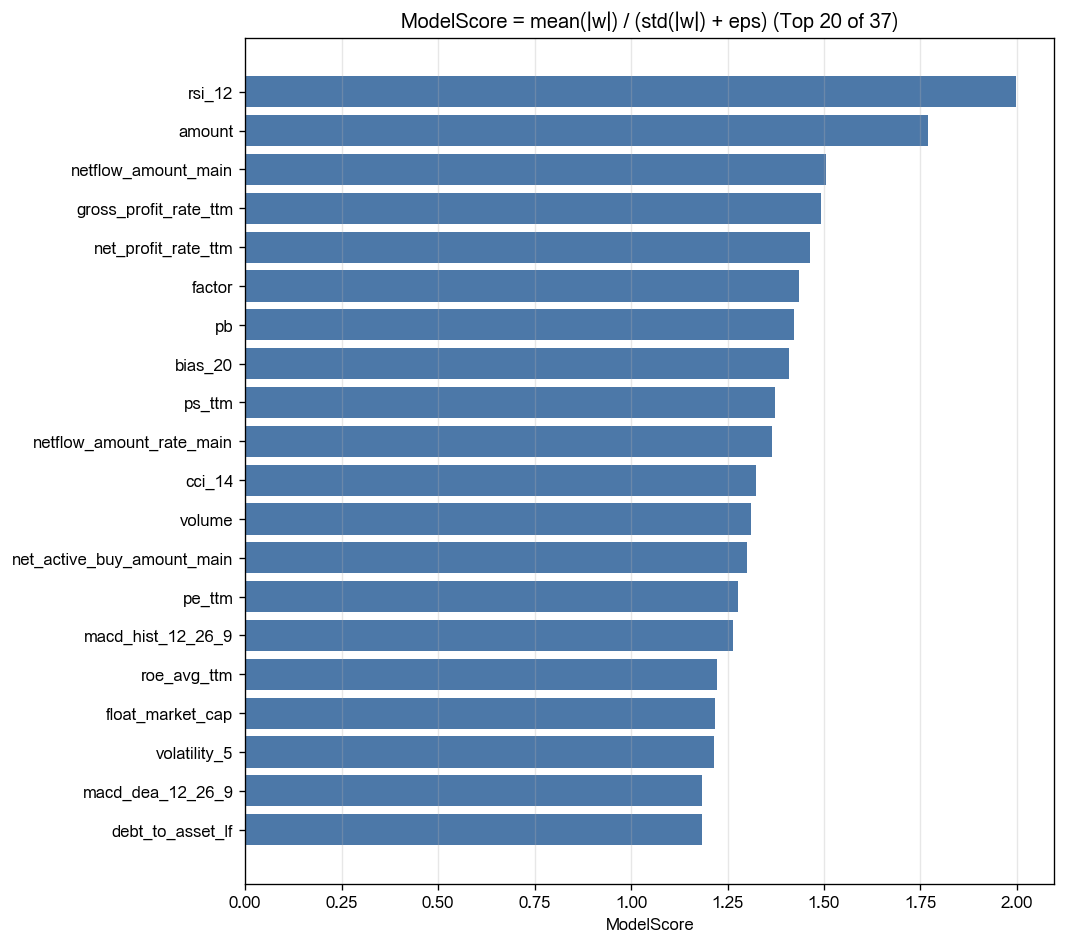
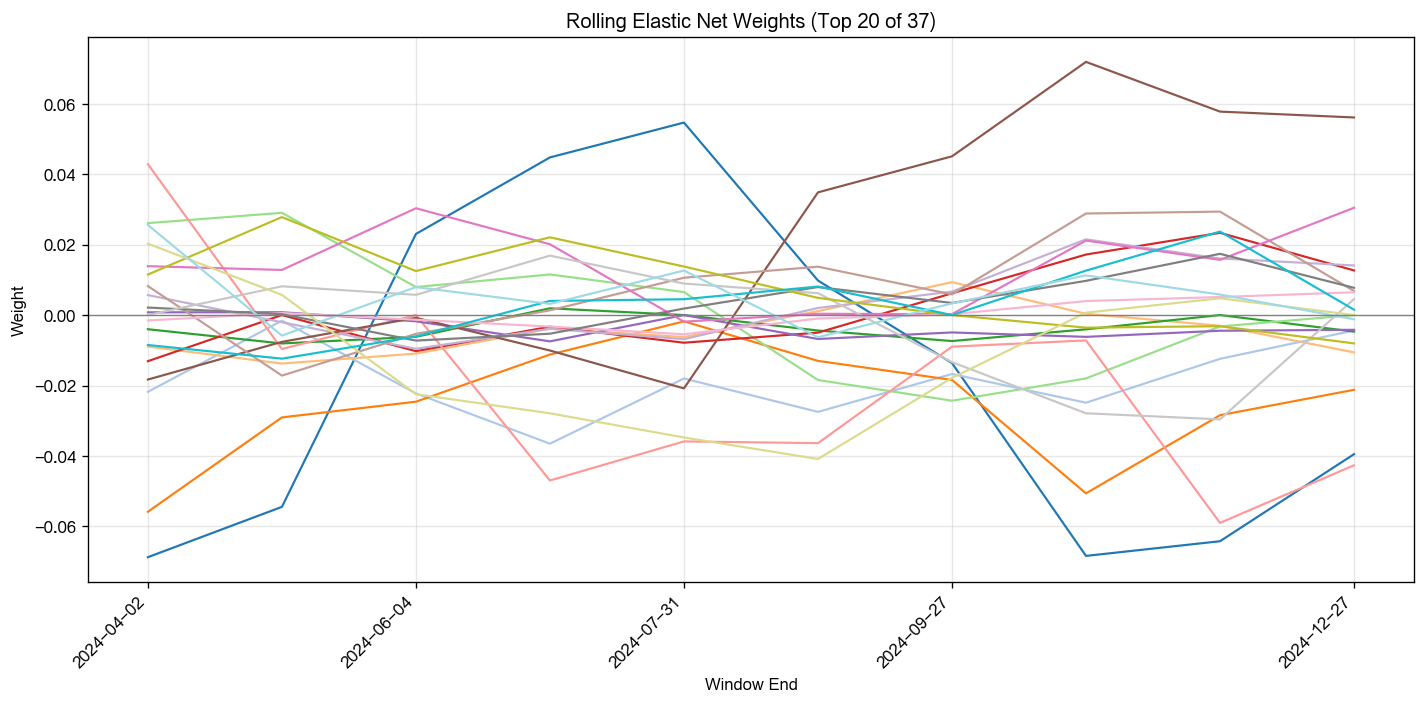
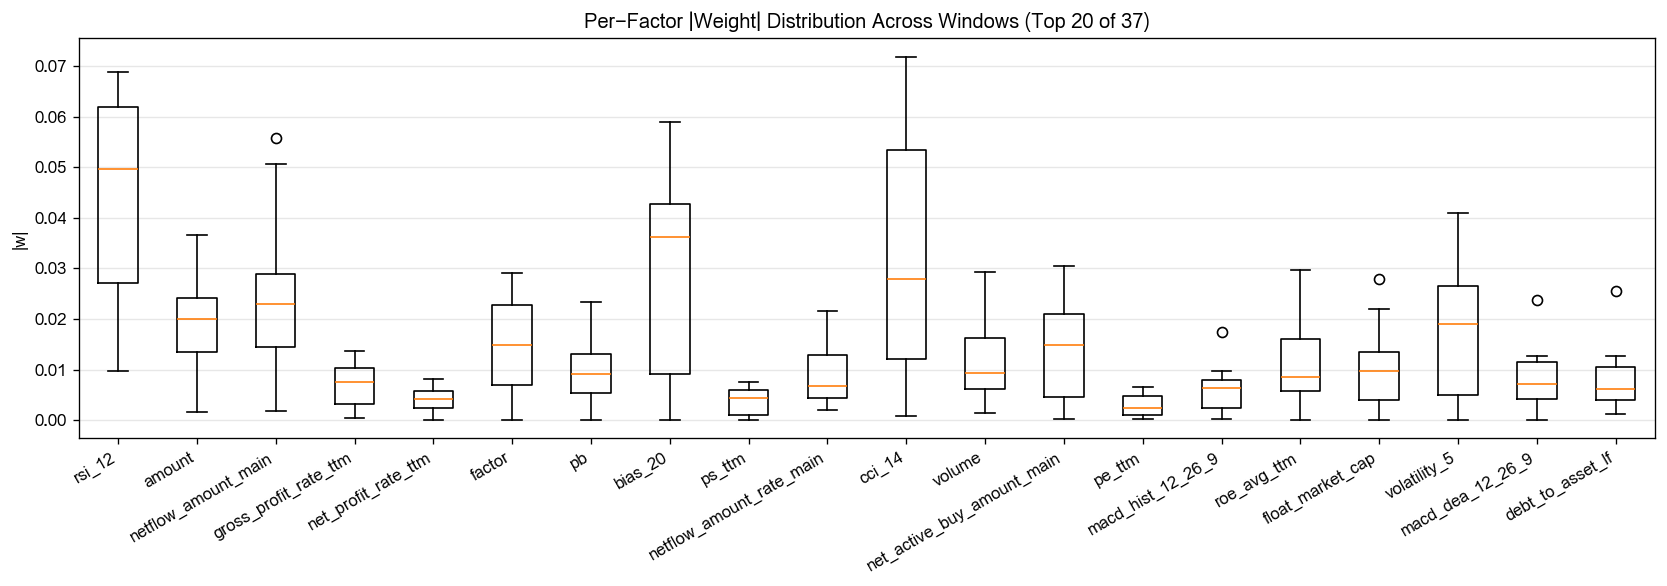
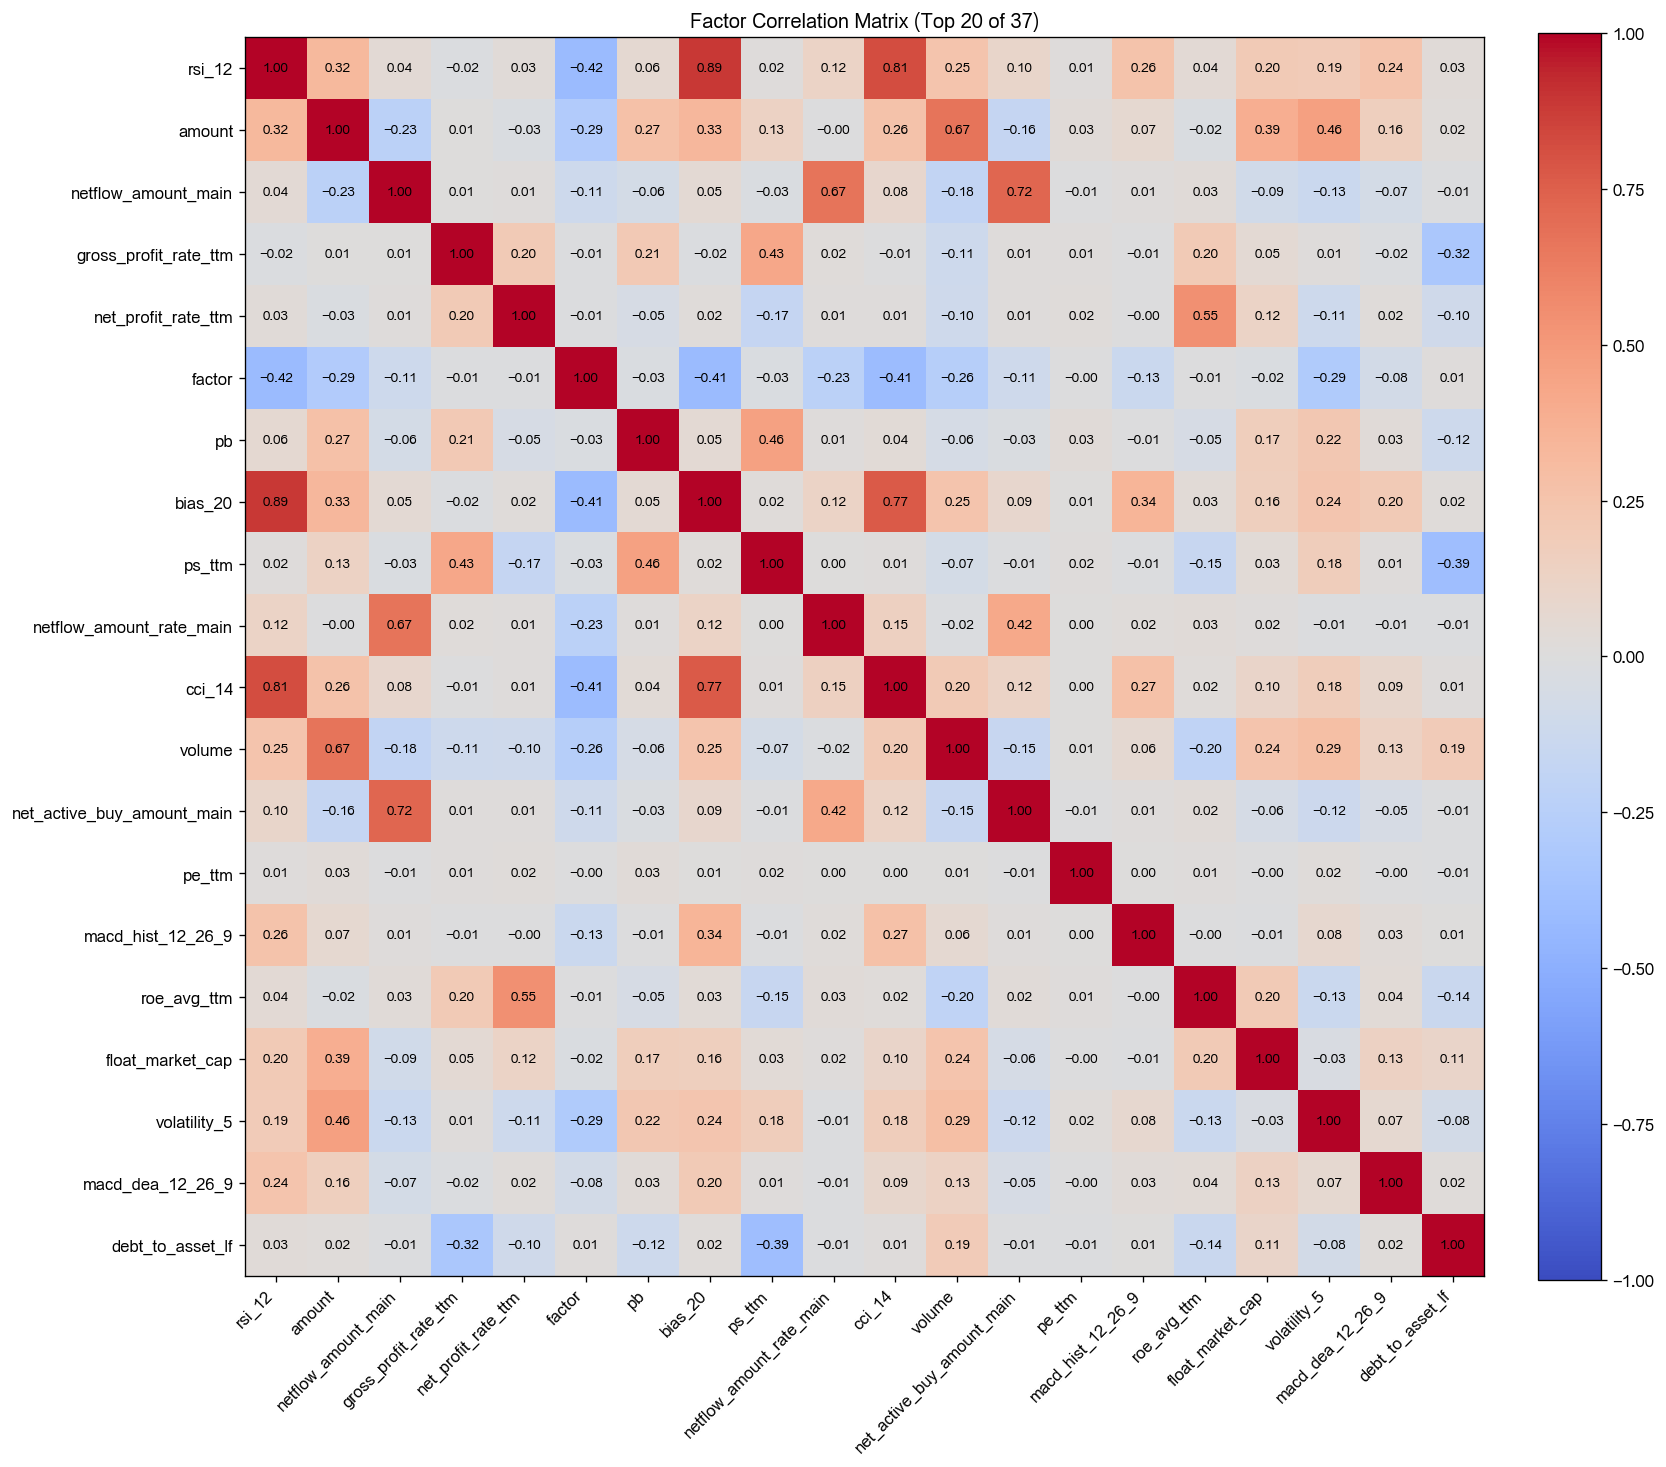

[2026-08-02 06:23:57] [warning  ] 返回的Outputs实例(size=35281906) 大于 64K, 将不会被缓存
[2026-08-02 06:23:57] [info     ] bigalpha_eval.v4 运行完成 [30.687s].


In [4]:
from __future__ import annotations
import numpy as np
import pandas as pd
import dai
import lightgbm as lgb
TRAIN_WINDOWS = [('2021-01-01 00:00:00', '2023-12-31 23:59:59', 1.0)]
TRAIN_START = min((window[0] for window in TRAIN_WINDOWS))
TRAIN_END = max((window[1] for window in TRAIN_WINDOWS))
TRAIN_BAR1M_TABLE = 'bigalpha_2026_stock_bar1m'
TARGET_BUFFER_DAYS = 180
LABEL_FORWARD_DAYS = 1
FAIR_C = 1.0
MODEL_SPECS = [('huber', 0.9, 1.0)]
MAX_DEPTH = 4
MIN_CHILD_SAMPLES = 80
KALMAN_LOOKBACK = 60
SUBSAMPLE_FREQ = 0
FEATURES = ['kalman_reversal', 'ret_5', 'ret_20', 'intraday_vol_m5', 'intraday_vol_m20', 'vol_ratio_z', 'vwap_twap_ratio', 'pv_power_m5', 'range_norm', 'overnight_open_return']

def _query_bar1m_daily(bar1m_table: str, start_date: str, end_date: str) -> pd.DataFrame:
    pv_power_expression = 'sum((close - open) * volume) / NULLIF(sum(volume), 0)'
    sql = f"\n        WITH daily_base AS (\n            SELECT\n                date_trunc('day', date)::DATE AS date,\n                instrument,\n                arg_min(open, date) AS open,\n                max(high) AS high,\n                min(low) AS low,\n                arg_max(close, date) AS close,\n                sum(volume) AS volume,\n                sum(amount) AS amount,\n                stddev(\n                    CASE WHEN close > 0 AND open > 0 THEN ln(close / open) ELSE NULL END\n                ) AS intraday_vol,\n                sum(CASE WHEN close > open THEN volume ELSE 0 END)\n                    / NULLIF(sum(volume), 0) AS buy_volume_ratio,\n                (sum(amount) / NULLIF(sum(volume), 0))\n                    / NULLIF(avg(close), 0) AS vwap_twap_ratio,\n                {pv_power_expression} AS pv_power,\n                max(high) - min(low) AS intraday_range\n            FROM {bar1m_table}\n            WHERE date >= TIMESTAMP '{start_date}'\n              AND date <= TIMESTAMP '{end_date}'\n            GROUP BY 1, 2\n        ),\n        daily_with_prev AS (\n            SELECT *,\n                LAG(close, 1) OVER (PARTITION BY instrument ORDER BY date) AS prev_close\n            FROM daily_base\n        )\n        SELECT\n            date, instrument, open, high, low, close, volume, amount,\n            intraday_vol, buy_volume_ratio, vwap_twap_ratio, pv_power, intraday_range,\n            open / NULLIF(prev_close, 0) - 1 AS overnight_open_return\n        FROM daily_with_prev\n        ORDER BY date, instrument\n        "
    raw = dai.query(sql).df()
    if raw is None or raw.empty:
        raise RuntimeError(f'bar query returned no rows for {start_date}..{end_date}')
    raw['date'] = pd.to_datetime(raw['date']).dt.normalize()
    numeric_cols = [c for c in raw.columns if c not in ('date', 'instrument')]
    for col in numeric_cols:
        raw[col] = pd.to_numeric(raw[col], errors='coerce')
    return raw.sort_values(['instrument', 'date']).reset_index(drop=True)

def _add_causal_kalman_reversal(daily_df: pd.DataFrame) -> pd.DataFrame:
    df = daily_df.sort_values(['instrument', 'date']).reset_index(drop=True).copy()
    all_dates = pd.Index(sorted(pd.to_datetime(df['date']).dropna().unique()))
    date_to_ordinal = {date: i for i, date in enumerate(all_dates)}
    df['_market_date_ordinal'] = pd.to_datetime(df['date']).map(date_to_ordinal)
    output = np.full(len(df), np.nan, dtype=float)
    eps = 1e-06
    for _, indices in df.groupby('instrument', sort=False).groups.items():
        idx = np.asarray(list(indices), dtype=int)
        close = pd.to_numeric(df.loc[idx, 'close'], errors='coerce').to_numpy(dtype=float)
        ordinal = pd.to_numeric(df.loc[idx, '_market_date_ordinal'], errors='coerce').to_numpy(dtype=float)
        log_price = np.full(len(idx), np.nan, dtype=float)
        valid_close = np.isfinite(close) & (close > 0)
        log_price[valid_close] = np.log(close[valid_close])
        step_is_contiguous = np.zeros(len(idx), dtype=bool)
        if len(idx) > 1:
            step_is_contiguous[1:] = np.diff(ordinal) == 1
        returns = pd.Series(log_price).diff()
        returns.loc[~step_is_contiguous] = np.nan
        lagged_return = returns.shift(1)
        gamma0 = lagged_return.rolling(KALMAN_LOOKBACK, min_periods=KALMAN_LOOKBACK).var(ddof=1)
        gamma1 = lagged_return.rolling(KALMAN_LOOKBACK, min_periods=KALMAN_LOOKBACK).cov(returns.shift(2))
        gamma0_values = gamma0.to_numpy(dtype=float)
        gamma1_values = gamma1.to_numpy(dtype=float)
        r_values = np.full(len(idx), np.nan, dtype=float)
        q_values = np.full(len(idx), np.nan, dtype=float)
        valid_moments = np.isfinite(gamma0_values) & np.isfinite(gamma1_values) & (gamma0_values > 0)
        if valid_moments.any():
            g0 = gamma0_values[valid_moments]
            r_estimate = -gamma1_values[valid_moments]
            r_estimate = np.minimum(np.maximum(r_estimate, eps * g0), (0.5 - eps) * g0)
            q_estimate = np.maximum(g0 - 2.0 * r_estimate, eps * g0)
            r_values[valid_moments] = r_estimate
            q_values[valid_moments] = q_estimate
        level = np.nan
        variance = np.nan
        for local_i, global_i in enumerate(idx):
            z = log_price[local_i]
            if not np.isfinite(z):
                level = np.nan
                variance = np.nan
                continue
            if local_i == 0 or not step_is_contiguous[local_i]:
                level = z
                variance = np.nan
                continue
            q_t = q_values[local_i]
            r_t = r_values[local_i]
            if not (np.isfinite(q_t) and np.isfinite(r_t)):
                level = z
                variance = np.nan
                continue
            if not np.isfinite(level):
                level = log_price[local_i - 1]
            if not np.isfinite(variance):
                variance = gamma0_values[local_i]
            if not (np.isfinite(level) and np.isfinite(variance) and (variance > 0)):
                level = z
                variance = np.nan
                continue
            predicted_variance = variance + q_t
            innovation_variance = predicted_variance + r_t
            if not np.isfinite(innovation_variance) or innovation_variance <= 0:
                level = z
                variance = np.nan
                continue
            innovation = z - level
            output[global_i] = -innovation / np.sqrt(innovation_variance)
            gain = predicted_variance / innovation_variance
            level = level + gain * innovation
            variance = (1.0 - gain) * predicted_variance
    df['kalman_reversal'] = output
    return df.drop(columns=['_market_date_ordinal'])

def _engineer_features(daily_df: pd.DataFrame) -> pd.DataFrame:
    df = daily_df.copy()
    g = df.groupby('instrument', group_keys=False)
    df['ret_5'] = g['close'].pct_change(5)
    df['ret_20'] = g['close'].pct_change(20)
    df['intraday_vol_m5'] = g['intraday_vol'].rolling(5).mean().reset_index(level=0, drop=True)
    df['intraday_vol_m20'] = g['intraday_vol'].rolling(20).mean().reset_index(level=0, drop=True)
    vol_mean = g['buy_volume_ratio'].rolling(20).mean().reset_index(level=0, drop=True)
    vol_std = g['buy_volume_ratio'].rolling(20).std().reset_index(level=0, drop=True)
    df['vol_ratio_z'] = (df['buy_volume_ratio'] - vol_mean) / vol_std
    df['pv_power_m5'] = g['pv_power'].rolling(5).mean().reset_index(level=0, drop=True)
    df['range_norm'] = df['intraday_range'] / df['close'].replace(0, np.nan)
    df = _add_causal_kalman_reversal(df)
    return df

def _rank_normalize(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    out[cols] = out[cols].replace([np.inf, -np.inf], np.nan)
    for col in cols:
        out[col] = (out.groupby('date')[col].rank(pct=True) - 0.5) * 2.0
    return out

def _fit_model(train: pd.DataFrame, features: list[str], objective: str, robust_alpha: float) -> lgb.LGBMRegressor:
    model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, max_depth=MAX_DEPTH, num_leaves=31, min_child_samples=MIN_CHILD_SAMPLES, subsample=0.7, subsample_freq=SUBSAMPLE_FREQ, bagging_seed=2026, colsample_bytree=0.7, reg_lambda=20.0, objective=objective, alpha=robust_alpha, fair_c=FAIR_C, random_state=2026, n_jobs=-1, verbose=-1)
    model.fit(train[features], train['label'])
    return model

def _align_and_validate_output(result: pd.DataFrame, start_date: str, end_date: str) -> pd.DataFrame:
    required = ['date', 'instrument', 'factor']
    if list(result.columns) != required:
        result = result[required]
    result = result.copy()
    result['date'] = pd.to_datetime(result['date']).dt.normalize()
    if result.duplicated(['date', 'instrument']).any():
        raise RuntimeError('duplicate date/instrument rows in factor output')
    result['factor'] = pd.to_numeric(result['factor'], errors='coerce')
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    universe = dai.query('SELECT date, instrument FROM bigalpha_2026_instruments', filters={'date': [start_date, end_date]}).df()
    if universe is None or universe.empty:
        raise RuntimeError('instrument-universe query returned no rows')
    universe['date'] = pd.to_datetime(universe['date']).dt.normalize()
    universe = universe[['date', 'instrument']].drop_duplicates()
    out = result.merge(universe, on=['date', 'instrument'], how='inner', validate='one_to_one')
    out['factor'] = out['factor'].astype(float)
    if not np.isfinite(out['factor'].to_numpy()).all():
        raise RuntimeError('non-finite factor values remain after alignment')
    if out['date'].nunique() != universe['date'].nunique():
        raise RuntimeError('factor output is missing one or more trading days')
    daily_output_count = out.groupby('date')['instrument'].nunique()
    daily_universe_count = universe.groupby('date')['instrument'].nunique()
    coverage = daily_output_count.div(daily_universe_count).fillna(0.0)
    if coverage.min() < 0.6:
        raise RuntimeError(f'minimum daily factor coverage is only {coverage.min():.1%}')
    varying_days = out.groupby('date')['factor'].std().fillna(0.0).gt(1e-12).mean()
    if varying_days < 0.8:
        raise RuntimeError(f'factor is cross-sectionally constant on too many days: {varying_days:.1%} varying')
    return out[['date', 'instrument', 'factor']]

def main(datasources, start_date, end_date):
    features = FEATURES
    train_daily = _query_bar1m_daily(TRAIN_BAR1M_TABLE, TRAIN_START, TRAIN_END)
    train_daily = _engineer_features(train_daily)
    train_daily['label'] = train_daily.groupby('instrument', group_keys=False)['close'].shift(-LABEL_FORWARD_DAYS) / train_daily['close'] - 1.0
    train_daily['label'] = train_daily['label'].replace([np.inf, -np.inf], np.nan)
    train_daily = _rank_normalize(train_daily, features)
    train_daily['label'] = (train_daily.groupby('date')['label'].rank(pct=True) - 0.5) * 2.0
    fitted_models = []
    for window_start, window_end, window_weight in TRAIN_WINDOWS:
        window_mask = (train_daily['date'] >= pd.Timestamp(window_start).normalize()) & (train_daily['date'] <= pd.Timestamp(window_end).normalize())
        train = train_daily[window_mask].dropna(subset=features + ['label'])
        if len(train) < 10000:
            raise RuntimeError(f'unexpectedly small training sample for {window_start}..{window_end}: {len(train)} rows')
        for objective, robust_alpha, objective_weight in MODEL_SPECS:
            combined_weight = float(window_weight) * float(objective_weight)
            if combined_weight <= 0:
                continue
            fitted_models.append((_fit_model(train, features, objective, float(robust_alpha)), combined_weight))
    if not fitted_models:
        raise RuntimeError('no positive-weight models were fitted')
    buffer_start = (pd.Timestamp(start_date) - pd.Timedelta(days=TARGET_BUFFER_DAYS)).strftime('%Y-%m-%d %H:%M:%S')
    target_daily = _query_bar1m_daily(datasources['bar1m'], buffer_start, end_date)
    target_daily = _engineer_features(target_daily)
    target_daily = _rank_normalize(target_daily, features)
    target = target_daily[(target_daily['date'] >= pd.Timestamp(start_date).normalize()) & (target_daily['date'] <= pd.Timestamp(end_date).normalize())].copy()
    target[features] = target[features].fillna(0.0)
    if len(fitted_models) == 1 and fitted_models[0][1] == 1.0:
        target['factor'] = fitted_models[0][0].predict(target[features])
    else:
        total_weight = sum((weight for _, weight in fitted_models))
        prediction = np.zeros(len(target), dtype=float)
        for model, weight in fitted_models:
            prediction += weight * model.predict(target[features])
        target['factor'] = prediction / total_weight
    result = target[['date', 'instrument', 'factor']].dropna(subset=['factor'])
    return _align_and_validate_output(result, start_date, end_date)
